# Cross-resistance across drugs (original dataset)

> **What the graphs show.** `burden_f420_activation` points into both the delamanid and pretomanid MICs. Several efflux-cluster variants point into both the bedaquiline and clofazimine MICs, with the signal split across those variants. The linezolid MIC receives no driver edge. Interpretation is left to the reader.

See [README.md](README.md) for how to read these graphs, the reliability number, the node colours, the pooled burdens, and the modelling choices.

**Design.** All the drug MICs go into one graph, and MIC <-> MIC edges are forbidden. With those edges blocked, two drug MICs can only end up correlated through a feature that points into both of them. So any feature with an arrow into more than one MIC is, by construction, a shared driver of those drugs.

Linezolid has no resistant strains in this dataset, so its MIC is kept only as a negative control: a genuine shared driver of the other drugs should not also point into it.

Resistance *type* is left out of these graphs on purpose: the type label is defined from resistance to other drugs, so in the graph it sits below those MICs rather than above them, and conditioning on it would feed outcome information back in.

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[2]))
from src.causal_discovery.cmm_utils import show_graph, parents_of, parents_across, plot_parents_across

/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yasmineparent/internship/tb_internship/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Focused graph: burden_f420_activation -> delamanid / pretomanid

Just this burden and the two MICs. If the group is a shared driver of both drugs, its burden should point into both MICs.

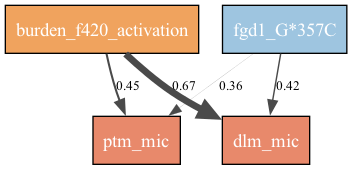

In [2]:
show_graph('tb_multidrug_focused_f420_dlm_ptm', ['dlm_mic', 'ptm_mic'])

In [3]:
parents_of('tb_multidrug_focused_f420_dlm_ptm', 'dlm_mic')

,source,frequency
0,burden_f420_activation,0.67
1,fgd1_G*357C,0.42
2,lineage_2,0.20
3,lineage_4,0.12


## Focused graph: burden_efflux -> bedaquiline / clofazimine

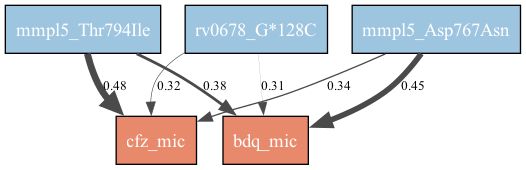

In [4]:
show_graph('tb_multidrug_focused_efflux_bdq_cfz', ['bdq_mic', 'cfz_mic'])

In [5]:
parents_of('tb_multidrug_focused_efflux_bdq_cfz', 'cfz_mic')

,source,frequency
0,mmpl5_Thr794Ile,0.48
1,mmpl5_Asp767Asn,0.34
2,rv0678_G*128C,0.32
3,rv1979c_C*135G,0.29
4,burden_efflux,0.23
5,pepq_Ala87Gly,0.22
6,lineage_4,0.10
7,lineage_2,0.10


## Joint graph, all drugs (agnostic; linezolid = negative control)

Every MIC and every candidate feature in one graph, with no prior assumption about which feature drives which drug. The reliability cutoff is lowered to 0.25 here because the joint graph spreads the same data across many competing edges, so each individual edge survives less often.

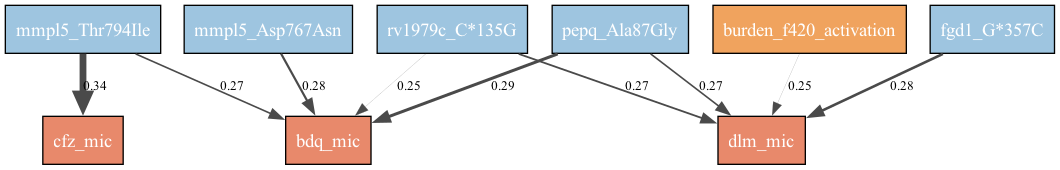

In [6]:
show_graph('tb_multidrug_dlm_ptm_bdq_cfz_lnz', ['dlm_mic','ptm_mic','bdq_mic','cfz_mic','lnz_mic'], 0.25)

## Complete structure (mutation -> lineage co-occurrence)

The same joint graph with `into_only=False`: this adds the background edges the focused views drop, in particular mutation -> lineage. An arrow from a mutation into a lineage just means they tend to occur together; nothing ever points from lineage into a mutation.

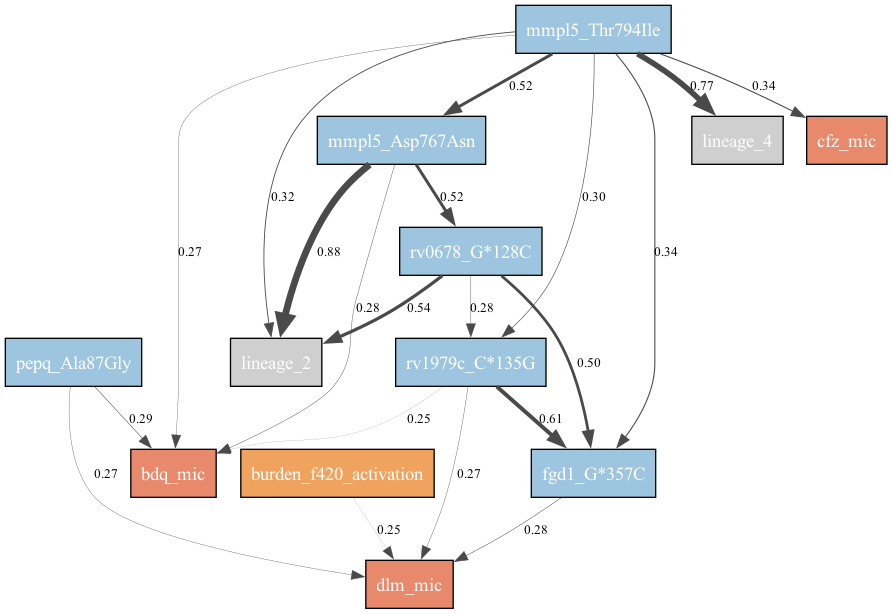

In [7]:
show_graph('tb_multidrug_dlm_ptm_bdq_cfz_lnz', ['dlm_mic','ptm_mic','bdq_mic','cfz_mic','lnz_mic'], 0.25, into_only=False)

## Reading the results

- `burden_f420_activation -> delamanid` is the strongest shared-driver edge, and the same burden also reaches pretomanid.
- The efflux signal is present but split: the same `mmpl5` / `rv0678` / `rv1979c` variants point into both bedaquiline and clofazimine, but because they tend to co-occur, the reliability score is divided among them and none clears 0.5.
- The joint graph is weaker than the focused graphs, which concentrate the signal on fewer edges. The linezolid MIC receives no driver edge, as expected for the negative control.